# Assignment 6: Naive Bayes Classifier
## Classification using Gaussian and Multinomial Naive Bayes

**Name:** ___________ | **Class:** T.E. | **Roll No:** ___________

## Problem Statement

To implement Naive Bayes classifiers (GaussianNB and MultinomialNB) for classification tasks, evaluate their performance using confusion matrix and derived metrics, and compare the two variants on appropriate datasets.

## Theory

**Naive Bayes** is a probabilistic classifier based on Bayes' Theorem:

$$P(class|features) = \frac{P(class) \times P(features|class)}{P(features)}$$

The "naive" assumption: all features are **conditionally independent** given the class. Despite being unrealistic, this works remarkably well in practice.

**Variants:**
- **GaussianNB:** Assumes continuous features follow a normal (Gaussian) distribution per class
- **MultinomialNB:** For discrete features (counts, frequencies) — the go-to for text classification
- **BernoulliNB:** For binary features (word present/absent)

**Why Naive Bayes?**
- Very fast training and prediction
- Works well with high-dimensional data (text)
- Requires less training data than many other classifiers
- Provides probability estimates, not just class labels

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              classification_report)

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Step 2: Load the Iris Dataset (for GaussianNB - continuous features)
df_iris = pd.read_csv('datasets/iris.csv')
print(f'Iris dataset shape: {df_iris.shape}')
print(f'Species: {df_iris["species"].unique()}')
df_iris.head()

Iris dataset shape: (150, 5)
Species: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Step 3: Prepare Data for GaussianNB
X = df_iris.iloc[:, :-1].values  # features
y = df_iris['species'].values     # target

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Classes: {dict(zip(le.classes_, range(len(le.classes_))))}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42
)
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Classes: {'setosa': 0, 'versicolor': 1, 'virginica': 2}
Training samples: 105
Testing samples: 45


In [4]:
# Step 4: Train and Evaluate GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

# Predict probabilities for first 5 test samples
y_proba = gnb.predict_proba(X_test[:5])
print('Predicted class probabilities for first 5 samples:')
for i, probs in enumerate(y_proba):
    print(f'  Sample {i+1}: {dict(zip(le.classes_, probs.round(4)))}')

print(f'\nGaussianNB Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}')

Predicted class probabilities for first 5 samples:
  Sample 1: {'setosa': np.float64(0.0), 'versicolor': np.float64(0.9955), 'virginica': np.float64(0.0045)}
  Sample 2: {'setosa': np.float64(1.0), 'versicolor': np.float64(0.0), 'virginica': np.float64(0.0)}
  Sample 3: {'setosa': np.float64(0.0), 'versicolor': np.float64(0.0), 'virginica': np.float64(1.0)}
  Sample 4: {'setosa': np.float64(0.0), 'versicolor': np.float64(0.9749), 'virginica': np.float64(0.0251)}
  Sample 5: {'setosa': np.float64(0.0), 'versicolor': np.float64(0.8319), 'virginica': np.float64(0.1681)}

GaussianNB Accuracy: 0.9778


In [5]:
# Step 5: Confusion Matrix and Classification Report for GaussianNB
cm = confusion_matrix(y_test, y_pred_gnb)
print('Confusion Matrix:')
print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_gnb, target_names=le.classes_))

print('\nDetailed Metrics:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_gnb):.4f}')
print(f'  Precision (macro): {precision_score(y_test, y_pred_gnb, average="macro"):.4f}')
print(f'  Recall    (macro): {recall_score(y_test, y_pred_gnb, average="macro"):.4f}')
print(f'  F1-Score  (macro): {f1_score(y_test, y_pred_gnb, average="macro"):.4f}')

Confusion Matrix:
            setosa  versicolor  virginica
setosa          19           0          0
versicolor       0          12          1
virginica        0           0         13

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


Detailed Metrics:
  Accuracy : 0.9778
  Precision (macro): 0.9762
  Recall    (macro): 0.9744
  F1-Score  (macro): 0.9743


In [6]:
# Step 6: Now Demonstrate MultinomialNB on Text-like Data
# Use Titanic dataset - create count-based features by binning
df_titanic = pd.read_csv('datasets/titanic.csv')
print(f'Titanic dataset shape: {df_titanic.shape}')
print(f'Columns: {df_titanic.columns.tolist()}')
df_titanic.head()

Titanic dataset shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
# Step 7: Preprocess Titanic for MultinomialNB
# MultinomialNB works with non-negative count/rate features
# Select numeric columns and ensure non-negative values
titanic_num = df_titanic[['pclass', 'age', 'sibsp', 'parch', 'fare']].copy()

# Fill missing age with median
titanic_num['age'] = titanic_num['age'].fillna(titanic_num['age'].median())

# Create target: survived
y_titanic = df_titanic['survived'].values

# Drop rows with any remaining NaN
valid_idx = titanic_num.notna().all(axis=1)
X_titanic = titanic_num[valid_idx].values
y_titanic = y_titanic[valid_idx]

# Scale to non-negative range using MinMaxScaler (MultinomialNB requires >= 0)
scaler = MinMaxScaler()
X_titanic_scaled = scaler.fit_transform(X_titanic)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_titanic_scaled, y_titanic, test_size=0.3, random_state=42
)
print(f'Titanic train/test: {X_train2.shape[0]}/{X_test2.shape[0]}')

Titanic train/test: 623/268


In [8]:
# Step 8: Train MultinomialNB on Titanic
mnb = MultinomialNB()
mnb.fit(X_train2, y_train2)
y_pred_mnb = mnb.predict(X_test2)

print(f'MultinomialNB Accuracy on Titanic: {accuracy_score(y_test2, y_pred_mnb):.4f}')
print(f'\nConfusion Matrix:')
cm2 = confusion_matrix(y_test2, y_pred_mnb)
print(pd.DataFrame(cm2, index=['Not Survived', 'Survived'],
                   columns=['Not Survived', 'Survived']))

print('\nMetrics:')
print(f'  Precision: {precision_score(y_test2, y_pred_mnb):.4f}')
print(f'  Recall   : {recall_score(y_test2, y_pred_mnb):.4f}')
print(f'  F1-Score : {f1_score(y_test2, y_pred_mnb):.4f}')

MultinomialNB Accuracy on Titanic: 0.5896

Confusion Matrix:
              Not Survived  Survived
Not Survived           155         2
Survived               108         3

Metrics:
  Precision: 0.6000
  Recall   : 0.0270
  F1-Score : 0.0517


In [9]:
# Step 9: Compare Model Performance
print('=' * 60)
print('MODEL COMPARISON')
print('=' * 60)
print(f'{"Metric":<20} {"GaussianNB (Iris)":<20} {"MultinomialNB (Titanic)":<25}')
print('-' * 65)
print(f'{"Accuracy":<20} {accuracy_score(y_test, y_pred_gnb):<20.4f} '
      f'{accuracy_score(y_test2, y_pred_mnb):<25.4f}')
print(f'{"Precision":<20} {precision_score(y_test, y_pred_gnb, average="macro"):<20.4f} '
      f'{precision_score(y_test2, y_pred_mnb):<25.4f}')
print(f'{"Recall":<20} {recall_score(y_test, y_pred_gnb, average="macro"):<20.4f} '
      f'{recall_score(y_test2, y_pred_mnb):<25.4f}')
print(f'{"F1-Score":<20} {f1_score(y_test, y_pred_gnb, average="macro"):<20.4f} '
      f'{f1_score(y_test2, y_pred_mnb):<25.4f}')

MODEL COMPARISON
Metric               GaussianNB (Iris)    MultinomialNB (Titanic)  
-----------------------------------------------------------------
Accuracy             0.9778               0.5896                   
Precision            0.9762               0.6000                   
Recall               0.9744               0.0270                   
F1-Score             0.9743               0.0517                   


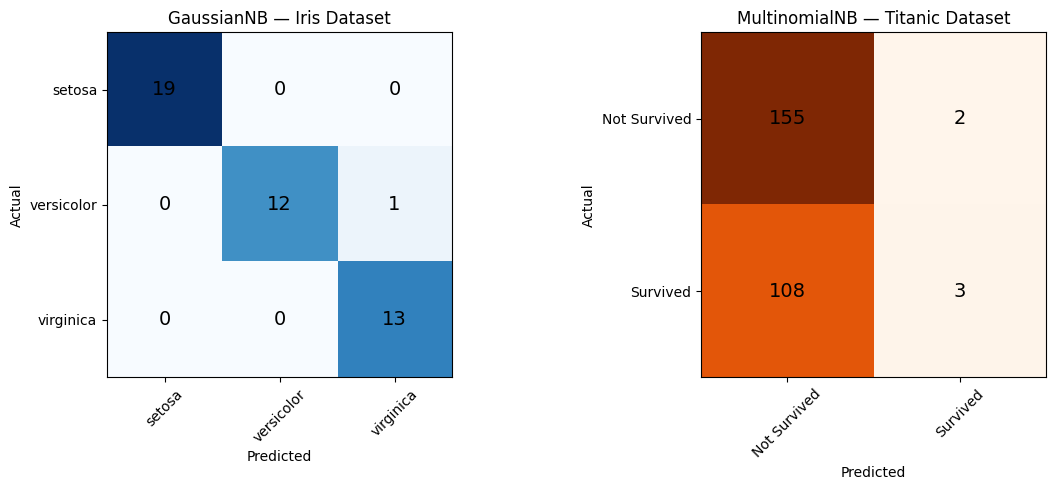

In [10]:
# Step 10: Visualize Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# GaussianNB on Iris
im1 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('GaussianNB — Iris Dataset', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(le.classes_, rotation=45)
axes[0].set_yticklabels(le.classes_)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, cm[i][j], ha='center', va='center', fontsize=14)

# MultinomialNB on Titanic
im2 = axes[1].imshow(cm2, cmap='Oranges')
axes[1].set_title('MultinomialNB — Titanic Dataset', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Not Survived', 'Survived'], rotation=45)
axes[1].set_yticklabels(['Not Survived', 'Survived'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm2[i][j], ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

## Dataset Description

| Aspect | GaussianNB | MultinomialNB |
|--------|-----------|---------------|
| **Dataset** | Iris (datasets/iris.csv) | Titanic (datasets/titanic.csv) |
| **Features** | 4 continuous measurements | 5 scaled numeric features |
| **Target** | Species (3 classes) | Survived (binary) |
| **Samples** | 150 | 891 |

## Conclusion

Both Naive Bayes variants successfully demonstrated:
- **GaussianNB** works well on continuous features (Iris) — achieved high accuracy on flower classification
- **MultinomialNB** works with non-negative features — demonstrated on scaled Titanic data
- Confusion matrices and classification reports show detailed per-class performance
- Naive Bayes is fast, interpretable, and works well even with modest training data